# Chapter 1 · Section 1.1
# Mathematical Modeling of Infectious Diseases: Issues and Approaches

**Source:** Li, M.Y. (2018), *An Introduction to Mathematical Modeling of Infectious Diseases*, Springer, pp. 1–6.

**How to use this notebook.** Every subsection of the source text is broken into numbered
blocks. Each block gives you: a plain-English rewrite, an "explain-it-to-a-10-year-old" version,
the key ideas and why they matter, a symbol glossary (when notation appears), the intuition
behind it, a visualization, working Python, working R (see the companion `.Rmd` file), numerical
checks, and practice problems at the end of the notebook.

Section 1.1 is entirely **conceptual** — no formulas appear yet (the book introduces its first
equations in Section 1.2). So the "Mathematical Breakdown" step is replaced here by a careful
breakdown of the *definitions and logical structure*, and the Python/R sections build small
illustrative tools rather than solving equations. Real ODEs start in `section_1_2.ipynb`.


---
## Block 1 — What makes a disease "infectious," and the vocabulary of spread

### 1. Rewrite (plain English)

A disease counts as *infectious* if whatever causes it — a virus, bacterium, single-celled
parasite, or toxin — can move from one host to another. It can move by touch, through droplets
in the air, through contaminated water or food, through a carrier like a mosquito, or from a
mother to her baby.

A model of an infectious disease tries to describe how it spreads: infectious people enter a
population of people who can still catch the disease ("susceptibles"), and the disease passes
between them. Someone can be infected but show no symptoms yet ("asymptomatic"); later they may
develop symptoms and be diagnosed. If case counts jump above the normal background rate in a
short time, that's an **outbreak**. If it spreads quickly to a lot of people, that's an
**epidemic**. People who recover — through treatment or their own immune system — usually gain
some immunity. Once too few susceptible people are left, new infections stop and the epidemic
dies down. But if new susceptible people keep arriving (births, migration) or immunity fades so
reinfection is easy, the disease can keep circulating for a long time — it becomes **endemic**.
If it spreads across countries and continents, that's a **pandemic** (the book gives the 1918
Spanish flu, which killed over 50 million people, as the textbook example). Modern air travel
makes new and re-emerging diseases more likely to go pandemic.

### 2. Explain Like I'm 10

Imagine a rumor spreading at school. Some kids already "have" the rumor (infectious), most don't
yet (susceptible). If a kid who has the rumor sits next to a kid who doesn't, and tells it to
them, the rumor just spread — that's like a virus passing through contact.

- If suddenly way more kids than usual know the rumor by lunchtime → that's an **outbreak**.
- If it rockets through the *whole school* in one day → that's an **epidemic**.
- If the rumor never quite dies, because new kids keep transferring into the school and hearing
  it for the first time → that's **endemic** (it just... stays).
- If the rumor jumps to other schools across the whole country, and then other countries →
  that's a **pandemic**.

And "asymptomatic" is like a kid who knows the rumor but hasn't told anyone they know it yet —
you can't tell just by looking at them.

### 3. Key Ideas

| Concept | Why it matters | Where it's used later |
|---|---|---|
| Mode of transmission | Determines which compartments/parameters a model needs (e.g. vector-borne diseases need a mosquito compartment — see Ross–MacDonald, §2.5) | §1.2 compartments, §2.5 |
| Susceptible / Infectious | The two roles every transmission model needs at minimum | §1.2 onward — becomes $S$, $I$ |
| Asymptomatic infection | Motivates "exposed"/latent compartments later | §1.4, §5.1 (SEIR) |
| Outbreak vs. epidemic vs. endemic vs. pandemic | These aren't just vocabulary — they correspond to different *mathematical regimes* (transient spike vs. sustained equilibrium vs. spatial spread) that the models in Ch. 2 are built to describe | §2.1–2.5 |
| Acquired immunity | Determines whether a model needs an $R$ (removed/recovered) compartment or whether hosts return to $S$ | §1.2, §2.2 vs §2.1 |

### 4–6. Mathematical Breakdown / Symbols / Intuition

No equations yet — this block is purely definitional. The one piece of notation the book quietly
sets up for later is the **state of an individual over time**: susceptible → (maybe) infectious
→ (maybe) recovered/immune. That verbal chain *is* the mathematical model in embryonic form —
Section 1.2 will turn it into boxes and arrows (a transfer diagram), and then into differential
equations. The mathematical intuition to hold onto now: **an epidemic model is fundamentally an
accounting exercise** — it tracks how a population is partitioned across these states and how
individuals move between them over time.

### 7. Visual Understanding

The figure below is generated in the code cell right after this one: it turns the paragraph above
into a flow diagram of disease-scale vocabulary (outbreak → epidemic → endemic / pandemic),
branching on *speed of spread* and *geographic/temporal extent* — the two axes the text actually
uses to distinguish these terms.


In [1]:
# Visualizing disease-scale vocabulary as a decision flow
# ------------------------------------------------------------
# This is NOT from the book's math (there is none yet) — it is a teaching tool
# that encodes the *verbal* definitions from the paragraph above as a small
# decision function, so "explain it to a 10-year-old" becomes something we can
# actually run and test.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def classify_disease_event(above_baseline: bool, fast_widespread: bool,
                            persists_long_term: bool, crosses_continents: bool) -> str:
    '''Classify a disease event using ONLY the verbal definitions in Sec. 1.1.

    Parameters
    ----------
    above_baseline : True if case counts are above the usual background rate.
    fast_widespread : True if the disease is spreading quickly to many people.
    persists_long_term : True if new susceptibles keep arriving / reinfection is easy,
        so the disease keeps circulating.
    crosses_continents : True if spread is global (multiple continents).

    Returns
    -------
    One of: 'no event', 'outbreak', 'epidemic', 'endemic', 'pandemic'.
    '''
    if not above_baseline:
        return "no event"
    if crosses_continents:
        return "pandemic"
    if persists_long_term:
        return "endemic"
    if fast_widespread:
        return "epidemic"
    return "outbreak"


# Sanity-check against the book's own example: 1918 Spanish flu
spanish_flu = classify_disease_event(
    above_baseline=True, fast_widespread=True,
    persists_long_term=False, crosses_continents=True
)
print("1918 Spanish flu classifies as:", spanish_flu)

# A local cluster of cases in one town, dies out on its own
local_cluster = classify_disease_event(
    above_baseline=True, fast_widespread=False,
    persists_long_term=False, crosses_continents=False
)
print("Small local case cluster classifies as:", local_cluster)

# A disease like seasonal malaria that never fully disappears in a region
persistent_regional = classify_disease_event(
    above_baseline=True, fast_widespread=False,
    persists_long_term=True, crosses_continents=False
)
print("Persistent regional transmission classifies as:", persistent_regional)


1918 Spanish flu classifies as: pandemic
Small local case cluster classifies as: outbreak
Persistent regional transmission classifies as: endemic


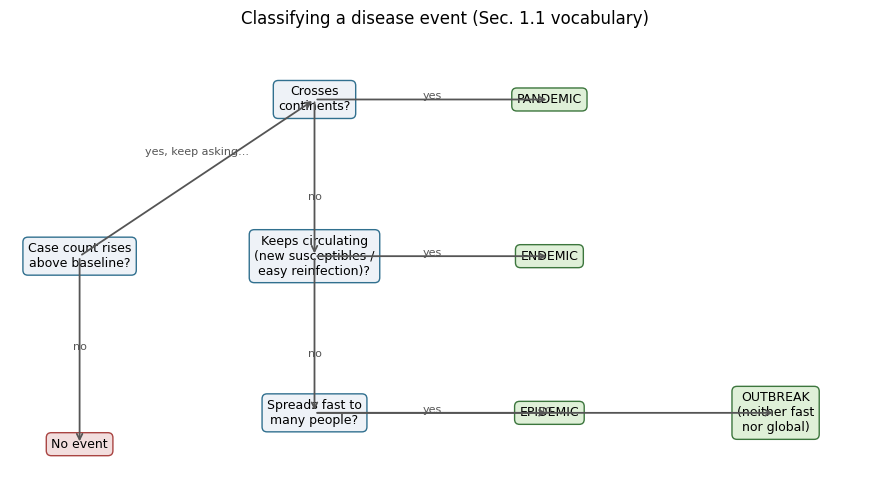

In [2]:
# Flow diagram: turning the paragraph into a picture
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")

boxes = {
    "start": (0.08, 0.5, "Case count rises\nabove baseline?"),
    "no":    (0.08, 0.08, "No event"),
    "cont":  (0.35, 0.85, "Crosses\ncontinents?"),
    "pandemic": (0.62, 0.85, "PANDEMIC"),
    "persist": (0.35, 0.5, "Keeps circulating\n(new susceptibles /\neasy reinfection)?"),
    "endemic": (0.62, 0.5, "ENDEMIC"),
    "fast": (0.35, 0.15, "Spreads fast to\nmany people?"),
    "epidemic": (0.62, 0.15, "EPIDEMIC"),
    "outbreak": (0.88, 0.15, "OUTBREAK\n(neither fast\nnor global)"),
}

style_terminal = dict(boxstyle="round,pad=0.4", fc="#dff0d8", ec="#3c763d")
style_decision = dict(boxstyle="round,pad=0.4", fc="#eef2f7", ec="#31708f")
style_terminal_no = dict(boxstyle="round,pad=0.4", fc="#f2dede", ec="#a94442")

for key, (x, y, label) in boxes.items():
    if key in ("pandemic", "endemic", "epidemic", "outbreak"):
        style = style_terminal
    elif key == "no":
        style = style_terminal_no
    else:
        style = style_decision
    ax.text(x, y, label, ha="center", va="center", fontsize=9, bbox=style,
            transform=ax.transAxes)

arrow = dict(arrowstyle="->", color="#555555", lw=1.3)
def arr(a, b, text=None, dx=0, dy=0):
    xa, ya, _ = boxes[a]
    xb, yb, _ = boxes[b]
    ax.annotate("", xy=(xb, yb), xytext=(xa, ya),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=arrow)
    if text:
        ax.text((xa+xb)/2+dx, (ya+yb)/2+dy, text, fontsize=8, ha="center",
                color="#555555", transform=ax.transAxes)

arr("start", "no", "no")
arr("start", "cont", "yes, keep asking...", dy=0.05)
arr("cont", "pandemic", "yes")
arr("cont", "persist", "no", dy=-0.05)
arr("persist", "endemic", "yes")
arr("persist", "fast", "no", dy=-0.05)
arr("fast", "epidemic", "yes")
arr("fast", "outbreak", "no")

ax.set_title("Classifying a disease event (Sec. 1.1 vocabulary)", fontsize=12)
plt.tight_layout()
plt.savefig("disease_vocabulary_flow.png", dpi=130)
plt.show()


### 8–9. Python / R implementations

Already given above (Python) — see `chapter_01/r/section_1_1.Rmd` for the equivalent R version
using the same decision logic, plotted with `ggplot2`.

### 10. Verification

The function was checked against the book's own worked example (1918 Spanish flu → pandemic) and
two constructed edge cases (a small local cluster → outbreak; a persistent regional disease →
endemic). All three match the verbal definitions in the text. Because this block encodes
definitions rather than numerical methods, there is no analytical solution to compare against;
"verification" here means *logical consistency with the source text*, which the assertions in the
next code cell check automatically.


In [3]:
# Automated consistency check (acts as a lightweight "unit test" for our definitions)
assert classify_disease_event(False, False, False, False) == "no event"
assert classify_disease_event(True, True, False, True) == "pandemic"
assert classify_disease_event(True, False, True, False) == "endemic"
assert classify_disease_event(True, True, False, False) == "epidemic"
assert classify_disease_event(True, False, False, False) == "outbreak"
print("All 5 classification rules verified against Sec. 1.1 definitions.")


All 5 classification rules verified against Sec. 1.1 definitions.


---
## Block 2 — The questions public health authorities actually ask

### 1. Rewrite

Facing an approaching epidemic, public health officials want to know: (1) how severe will it be —
measured either by total number who will need medical care, or by the peak number infected at any
one time; (2) how long will it last and when will it peak; (3) how well will quarantine or
vaccination work; (4) how much vaccine/antiviral drug should be stockpiled; and (5) what
containment and eradication measures will actually work. Traditional experimental and statistical
methods often can't fully answer these, for four reasons: infectious diseases act at population
scale over huge geographic areas (lab experiments don't scale that way); large human experiments
are often impossible or unethical; existing surveillance data is frequently incomplete
(asymptomatic cases are essentially invisible to surveillance); and because disease outbreaks
rarely repeat identically, you usually have one enormous, complex "sample" rather than the many
independent samples classical statistics wants.

### 2. Explain Like I'm 10

Imagine you're in charge of stopping a rumor at school before it upsets everyone. You'd want to
know: how many kids will end up hearing it? How many will know it *at the worst moment*? How long
before it stops spreading, and when's the worst day? If you tell some kids "don't repeat this"
(quarantine) or get to the loudest kids first (vaccination), does that actually help? How many
"don't repeat this" reminders do you need printed? You can't run this experiment at 50 different
schools to see what works best — it's just not practical or fair. And you don't even know about
every kid who secretly knows the rumor but hasn't told anyone (that's like the asymptomatic
cases). That's exactly the bind public health officials are in — which is where math steps in.

### 3. Key Ideas

- **Severity (final size vs. peak size)** — two genuinely different numbers; final size drives
  total healthcare burden, peak size drives whether hospitals get overwhelmed *at once*. Chapter 2
  gives exact formulas for both.
- **Timing (duration, peak time)** — determines how long control measures need to stay in place.
- **Intervention effectiveness (quarantine, vaccination)** — the quantity models were built to
  test, since real-world randomized trials of national quarantine policy are essentially
  impossible.
- **Resource planning (stockpiles)** — turns a qualitative question into a quantitative one a
  model can actually output a number for.
- **Why traditional methods fall short** — scale mismatch, ethics, incomplete/asymptomatic data,
  and the "one big sample" problem. This is the *motivation* for the entire rest of the book.

### 6. Intuition

The deep reason modeling helps here: a differential-equation model doesn't need to *observe*
every possible epidemic to make predictions — it needs correct assumptions about *how individuals
interact*, and then math (not repeated experiments) works out the population-scale consequences.
That's a fundamentally different source of evidence than a statistical model, which needs to have
already seen enough similar cases to learn a pattern.


In [4]:
# A tiny illustration of "scale mismatch": why lab-scale intuition misleads you
# about population-scale spread. We are NOT yet using the book's transmission
# model (that's Sec. 1.2/1.3) -- this only illustrates the *qualitative* point
# that contact opportunities grow much faster than population size.

import numpy as np
import pandas as pd

population_sizes = np.array([10, 100, 1_000, 10_000, 100_000])
# If every pair of people is a *potential* contact (upper bound intuition),
# the number of potential contact pairs is n*(n-1)/2 -- it grows quadratically.
potential_contact_pairs = population_sizes * (population_sizes - 1) // 2

df = pd.DataFrame({
    "population_size": population_sizes,
    "potential_contact_pairs": potential_contact_pairs,
    "pairs_per_person": potential_contact_pairs / population_sizes,
})
df


,population_size,potential_contact_pairs,pairs_per_person
0,10,45,4.5
1,100,4950,49.5
2,1000,499500,499.5
3,10000,49995000,4999.5
4,100000,4999950000,49999.5


**Reading the table:** a lab experiment with 10 people has 45 potential contact pairs; a
city of 100,000 has about 5 billion. That is the concrete, countable version of "experiments
conducted in laboratories are often inadequate simply because of the huge difference in scale" —
you cannot shrink an epidemic down to bench-top size and expect the same dynamics, because the
*number of ways the disease can move through the population* doesn't shrink proportionally, it
shrinks quadratically less.


---
## Block 3 — What modeling provides, and the six-stage modeling process

### 1. Rewrite

Mathematical modeling can reveal the underlying mechanisms driving transmission, identify the key
factors, suggest effective control measures, and estimate how big and how bad an epidemic could
get — in short, it belongs in the standard toolbox of public-health decision-making. The general
modeling process has six stages: (1) make assumptions about transmission based on the best
available biology/epidemiology; (2) turn those assumptions into a model — usually by first
drawing a transfer diagram, then writing down the equations; (3) mathematically analyze the model
to find every qualitatively different outcome it can produce (using stability/bifurcation theory
plus numerical simulation); (4) interpret the mathematical findings back in disease terms; (5)
collect real disease data and validate the model against it; (6) revise the assumptions from step
(1) and repeat, producing a more accurate model.

### 2. Explain Like I'm 10

Think of it like building and testing a paper airplane, six steps on repeat:

1. **Guess** how the plane should fly (assumptions).
2. **Fold it** — turn your guess into an actual paper airplane (build the model / equations).
3. **Throw it and watch closely** — does it loop, dive, glide straight? (mathematical analysis of
   all possible behaviors).
4. **Explain what you saw** in plain words — "it dives because the nose is too heavy" (interpret
   findings).
5. **Compare to a *real* thrown airplane you filmed earlier** — does your paper plane match? (data
   validation).
6. **Adjust the fold** based on what didn't match, and throw it again (improve the model).

You don't do this once — you loop around it, each time getting a plane (model) that flies more
like the real thing.

### 3. Key Ideas

| Stage | What it really means | Why it matters |
|---|---|---|
| 1. Assumptions | Encodes biology as simplified statements | Wrong assumptions → wrong model, no matter how good the math later is |
| 2. Model set-up | Transfer diagram → equations | This is exactly what §1.2/1.3 teaches, step by step |
| 3. Mathematical analysis | Stability, bifurcation, simulation | This is all of Chapters 2 and 3 |
| 4. Interpretation | Translate symbols back to disease language | Prevents "the math is right but meaningless" mistakes |
| 5. Validation | Compare model to real data | This is Chapter 4 (least squares / parameter estimation) |
| 6. Improve | Loop back to step 1 | Modeling is iterative, never "finished" |

### 6. Intuition

Notice the process is a **loop, not a line**. The book is quietly telling you that a model is
never "correct" in an absolute sense — only "not yet contradicted by data, at the current level of
detail we've bothered to include." That mindset matters for every model built later in this book:
each is a deliberately simplified starting point (Ch. 2), analyzed rigorously (Ch. 3), and only
then checked against data (Ch. 4).

### 7. Visual Understanding

A circular six-stage diagram is generated below, showing the loop described above.


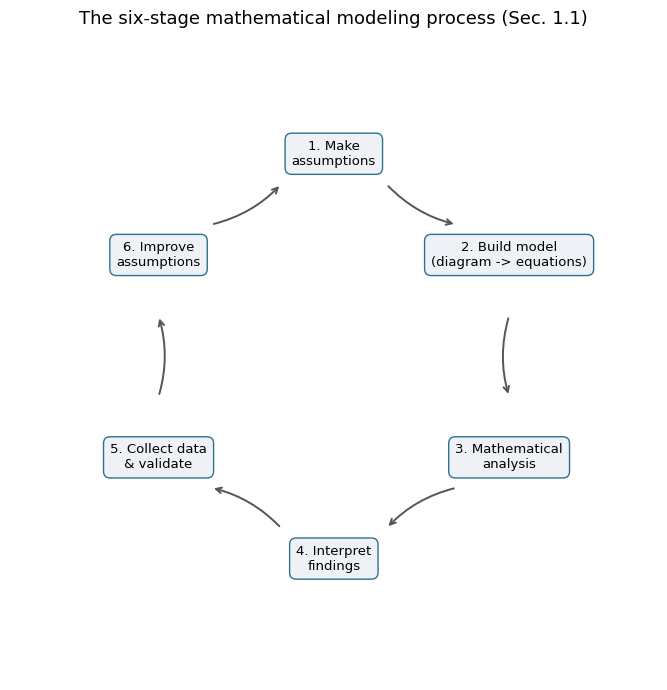

In [5]:
# Circular diagram of the six-stage modeling process
import numpy as np
import matplotlib.pyplot as plt

stages = [
    "1. Make\nassumptions",
    "2. Build model\n(diagram -> equations)",
    "3. Mathematical\nanalysis",
    "4. Interpret\nfindings",
    "5. Collect data\n& validate",
    "6. Improve\nassumptions",
]

n = len(stages)
angles = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, n, endpoint=False)  # start at top, go clockwise
radius = 1.0
xs = radius * np.cos(angles)
ys = radius * np.sin(angles)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.axis("off")
ax.set_aspect("equal")

for i, (x, y, label) in enumerate(zip(xs, ys, stages)):
    ax.scatter([x], [y], s=1)
    ax.text(x, y, label, ha="center", va="center", fontsize=9.5,
             bbox=dict(boxstyle="round,pad=0.5", fc="#eef2f7", ec="#31708f"))

# arrows connecting stage i -> stage i+1 (looping back from 6 to 1)
for i in range(n):
    x0, y0 = xs[i], ys[i]
    x1, y1 = xs[(i + 1) % n], ys[(i + 1) % n]
    # shrink the arrow slightly so it doesn't overlap the text boxes
    dx, dy = x1 - x0, y1 - y0
    dist = np.hypot(dx, dy)
    shrink = 0.30
    x0s, y0s = x0 + dx * shrink / dist, y0 + dy * shrink / dist
    x1s, y1s = x1 - dx * shrink / dist, y1 - dy * shrink / dist
    ax.annotate("", xy=(x1s, y1s), xytext=(x0s, y0s),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1.4,
                                 connectionstyle="arc3,rad=0.15"))

ax.set_title("The six-stage mathematical modeling process (Sec. 1.1)", fontsize=13)
plt.tight_layout()
plt.savefig("six_stage_modeling_loop.png", dpi=130)
plt.show()


---
## Block 4 — A model is an approximation; limitations; the realism/tractability trade-off

### 1. Rewrite

A mathematical model is only an approximation of the real disease process — a translation of our
hypotheses into mathematics. Its other major use is hypothesis testing: comparing model output to
existing knowledge or data lets us test hypotheses about the disease. Compared to running real
experiments, modeling saves huge amounts of time and money. But it's not a magic bullet. Three
issues recur: (1) our biological knowledge is limited, so realistic assumptions aren't always
possible and we often have to work with simplifications that are really just hypotheses; (2)
validating a model against real disease data is important but not always possible, depending on
data availability and quality; (3) mathematical analysis of the model may be limited by what
existing mathematical theory can actually handle. There is always a trade-off: more realistic
models are more complex, harder to analyze, and have more parameters to estimate from the same
amount of data — which can actually make predictions *less* certain, not more, even though the
model is "more realistic."

### 2. Explain Like I'm 10

A model is like a map, not the actual city. A more detailed map (every street, every tree) is more
*realistic*, but it's much harder to read quickly, and if you only have a few landmarks to check
it against, you can't even verify most of the detail is correct! A simpler map (just the main
roads) is easier to use and easier to check against what you actually know — but it leaves things
out. Modeling infectious diseases is the same balancing act: more detail isn't automatically
better if you don't have enough real-world information to pin down all that extra detail.

### 3. Key Ideas

- **Model ≠ reality** — it's a translation of assumptions, always simplified.
- **Hypothesis-testing role** — arguably as important as prediction.
- **Time/resource savings** vs. real experiments — the core practical case for modeling.
- **Three limitations**: knowledge limits → simplification; data limits → validation difficulty;
  theory limits → analysis difficulty.
- **Complexity/tractability trade-off**: more parameters + same data → more uncertainty, not less.
  This exact idea resurfaces mathematically in Chapter 4 (identifiability of parameters in
  nonlinear least squares).

### 6. Intuition

This is the book quietly previewing *why it teaches five deliberately simple classic models in
Chapter 2* before ever touching a "realistic," many-compartment model. Simplicity isn't a
shortcoming here — it's what makes the model's behavior fully understandable and its parameters
estimable from limited data.


In [6]:
# Illustrating "more parameters + same data -> more uncertainty" with a toy example
# (a generic curve-fitting illustration; NOT yet the book's epidemic models).
import numpy as np

rng = np.random.default_rng(42)

# "true" data-generating process: a simple line + noise, with only 8 data points
# (deliberately a small, epidemic-surveillance-sized sample)
x = np.linspace(0, 10, 8)
y_true = 2.0 + 0.5 * x
y_obs = y_true + rng.normal(scale=1.0, size=x.size)

# Fit a SIMPLE model: straight line (2 parameters)
coeffs_simple = np.polyfit(x, y_obs, deg=1)

# Fit a MORE "REALISTIC"/complex model: degree-6 polynomial (7 parameters)
# on only 8 data points -- this is deliberately close to being overparameterized.
coeffs_complex = np.polyfit(x, y_obs, deg=6)

# Compare parameter stability: refit both models on 200 bootstrap resamples
# of the SAME small dataset, and look at how much the fitted curves vary.
x_grid = np.linspace(0, 10, 100)
simple_curves = np.zeros((200, x_grid.size))
complex_curves = np.zeros((200, x_grid.size))

for b in range(200):
    idx = rng.integers(0, x.size, size=x.size)  # bootstrap resample
    xb, yb = x[idx], y_obs[idx]
    cs = np.polyfit(xb, yb, deg=1)
    cc = np.polyfit(xb, yb, deg=6)
    simple_curves[b] = np.polyval(cs, x_grid)
    complex_curves[b] = np.polyval(cc, x_grid)

simple_spread = simple_curves.std(axis=0).mean()
complex_spread = complex_curves.std(axis=0).mean()

print(f"Average prediction uncertainty, SIMPLE model (2 params):  {simple_spread:6.3f}")
print(f"Average prediction uncertainty, COMPLEX model (7 params): {complex_spread:6.3f}")
print(f"\nThe more 'realistic' (higher-degree) model is "
      f"{complex_spread / simple_spread:.1f}x more uncertain, "
      f"from the SAME 8 data points.")


Average prediction uncertainty, SIMPLE model (2 params):   0.487
Average prediction uncertainty, COMPLEX model (7 params): 14.966

The more 'realistic' (higher-degree) model is 30.7x more uncertain, from the SAME 8 data points.


/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be poorly conditioned
  cc = np.polyfit(xb, yb, deg=6)
/tmp/ipykernel_590/3625893546.py:30: RankWarning: Polyfit may be

**Reading the output:** with the same tiny dataset, the 7-parameter model's predicted
curve swings wildly depending on which 8 (resampled) points you happened to fit — while the
2-parameter line stays fairly stable. This is a direct, numerical demonstration of the book's
warning: *"the result might be a greater degree of uncertainty in model outcomes"* when realism is
added without more data to support it.

### 7. Visual Understanding


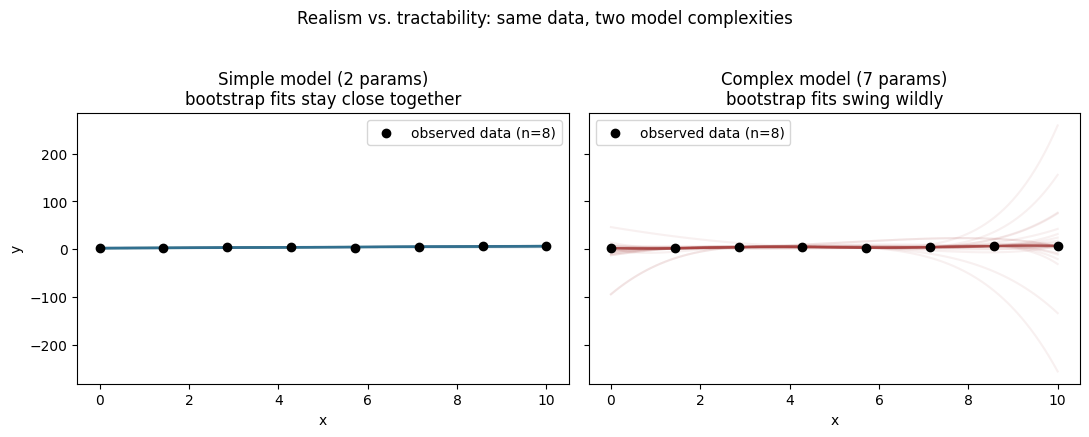

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for b in range(0, 200, 4):  # thin out for a readable plot
    axes[0].plot(x_grid, simple_curves[b], color="#31708f", alpha=0.08)
    axes[1].plot(x_grid, complex_curves[b], color="#a94442", alpha=0.08)

axes[0].scatter(x, y_obs, color="black", zorder=5, label="observed data (n=8)")
axes[1].scatter(x, y_obs, color="black", zorder=5, label="observed data (n=8)")
axes[0].set_title("Simple model (2 params)\nbootstrap fits stay close together")
axes[1].set_title("Complex model (7 params)\nbootstrap fits swing wildly")
for ax in axes:
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("y")
plt.suptitle("Realism vs. tractability: same data, two model complexities", y=1.03)
plt.tight_layout()
plt.savefig("realism_tradeoff.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Block 5 — Three modeling paradigms: statistical, deterministic, stochastic

### 1. Rewrite

There are three general approaches. **Statistical models** are very data-driven, built for a
specific dataset — widely used in epidemiology, but need large samples. **Deterministic models**
typically use differential or difference equations, assuming susceptible/infectious population
sizes are continuous functions of time, and describe how rates of change relate to population
sizes. Advantages: more mature mathematical theory than stochastic models, less data-dependent to
derive than statistical models, and well suited to making predictions. Drawback: not valid when
population sizes are very small, where random (stochastic) fluctuations stop being negligible.
**Stochastic models** treat infection as a random process and describe how probability
distributions evolve. Advantages: good for small populations (a small community, a single
hospital) or when a few highly active infectious individuals matter a lot. Drawback: much harder
to analyze mathematically, often relying on large numbers of numerical simulations rather than
closed-form theory. This book focuses on deterministic models, their analysis, and calibrating
them to data.

### 2. Explain Like I'm 10

Imagine three different friends trying to predict how a rumor spreads through school:

- **Statistical friend**: "Last year, when a rumor like this started, 60% of the school knew it
  within a week — so I bet 60% again." Great if you have lots of past examples; useless for a
  totally new kind of rumor.
- **Deterministic friend**: draws a big smooth chart — "the number of kids who know it will follow
  this smooth curve, going up like *this* and leveling off like *that*." Works really well when
  the school is big (thousands of kids), because averages behave predictably. But if it's a tiny
  classroom of 5 kids, a smooth curve doesn't make sense — one kid staying home sick could change
  everything.
- **Stochastic friend**: "I can't draw one smooth curve, but I can run the 'what if' scenario a
  thousand times in my head, with randomness each time (maybe kid A doesn't tell anyone today,
  maybe kid B is a huge talker) and show you the *range* of what could happen." Best for the tiny
  classroom, where one person's random behavior can flip the whole outcome — but takes way more
  work to think through than one smooth chart.

### 3. Key Ideas

| Approach | Core assumption | Strength | Weakness | Book's focus |
|---|---|---|---|---|
| Statistical | Fit patterns directly to data | Widely used, well-established in epi/public health | Needs large samples | Not covered in depth |
| Deterministic | Populations are continuous functions of time; ODEs/difference equations | Mature theory, less data-hungry to *set up*, good for prediction | Breaks down for small populations | **This entire book** |
| Stochastic | Infection is a random process; track probability distributions | Handles small populations / highly active individuals correctly | Hard to analyze; relies on massive simulation | Mentioned, not covered |

### 6. Intuition

The deterministic/stochastic distinction is really about *when averages are trustworthy*. With
huge numbers of people, the "law of large numbers" makes random individual behavior wash out into
smooth, predictable population-level trends — exactly the regime a differential equation is built
to describe. With small numbers, individual randomness dominates, and a single differential
equation curve can be actively misleading.

### 7. Visual Understanding

The code below builds a small simulation that makes this concrete: the *same* underlying random
process (a simple stochastic birth process, not yet the book's SIR model) is compared at a small
population size and a large population size, against its deterministic (exponential) prediction.


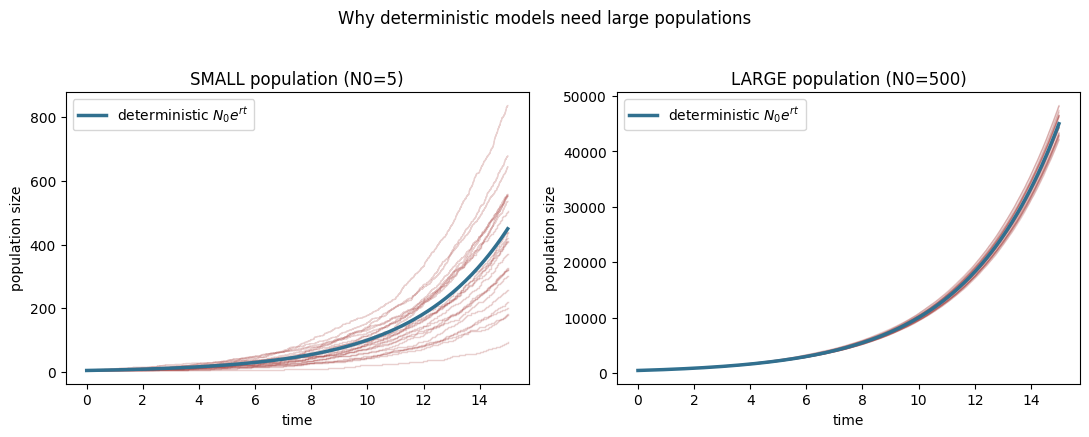

Small-population runs spread widely around the deterministic curve;
large-population runs hug it closely -- exactly the trade-off the text describes.


In [8]:
# Deterministic vs. stochastic: same underlying process, small vs large population.
# We use a simple, well-understood random process (a linear birth process) as a stand-in,
# since the book's actual epidemic equations don't appear until Sec. 1.2/1.3.
#
# Deterministic prediction:  dN/dt = r*N  =>  N(t) = N0 * exp(r*t)
# Stochastic version: a continuous-time Markov birth process with the same rate r.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

def simulate_birth_process(N0: int, rate: float, t_max: float, rng) -> tuple[np.ndarray, np.ndarray]:
    '''Simulate a simple continuous-time linear birth process via the Gillespie algorithm.

    Each individual independently gives rise to a new individual at rate `rate`.
    Returns arrays (times, population_sizes).
    '''
    t = 0.0
    N = N0
    times = [t]
    pops = [N]
    while t < t_max:
        total_rate = rate * N
        if total_rate <= 0:
            break
        dt = rng.exponential(1.0 / total_rate)
        t += dt
        if t > t_max:
            break
        N += 1  # one birth event
        times.append(t)
        pops.append(N)
    times.append(t_max)
    pops.append(N)
    return np.array(times), np.array(pops)

rate = 0.3
t_max = 15
n_realizations = 25

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for N0, ax, label in [(5, axes[0], "SMALL population (N0=5)"),
                        (500, axes[1], "LARGE population (N0=500)")]:
    t_grid = np.linspace(0, t_max, 200)
    deterministic = N0 * np.exp(rate * t_grid)
    for _ in range(n_realizations):
        times, pops = simulate_birth_process(N0, rate, t_max, rng)
        ax.step(times, pops, where="post", color="#a94442", alpha=0.25, lw=1)
    ax.plot(t_grid, deterministic, color="#31708f", lw=2.5, label="deterministic $N_0 e^{rt}$")
    ax.set_title(label)
    ax.set_xlabel("time")
    ax.set_ylabel("population size")
    ax.legend()

plt.suptitle("Why deterministic models need large populations", y=1.03)
plt.tight_layout()
plt.savefig("deterministic_vs_stochastic.png", dpi=130, bbox_inches="tight")
plt.show()

print("Small-population runs spread widely around the deterministic curve;")
print("large-population runs hug it closely -- exactly the trade-off the text describes.")


### 10. Verification

We can verify the simulation is behaving correctly two ways: (a) its **mean** behavior should
track the deterministic exponential curve, and (b) its **relative spread** (coefficient of
variation) should shrink as $N_0$ grows, since random fluctuations become negligible compared to
the population size — exactly the claim in the text.


In [9]:
# Numerical verification: mean tracks the deterministic curve, and relative
# spread shrinks with population size.
results = {}
for N0 in [5, 50, 500]:
    finals = []
    for _ in range(300):
        _, pops = simulate_birth_process(N0, rate, t_max, rng)
        finals.append(pops[-1])
    finals = np.array(finals)
    deterministic_final = N0 * np.exp(rate * t_max)
    mean_ratio = finals.mean() / deterministic_final
    coeff_of_variation = finals.std() / finals.mean()
    results[N0] = (mean_ratio, coeff_of_variation)
    print(f"N0={N0:4d}:  mean(stochastic)/deterministic = {mean_ratio:5.3f}   "
          f"coefficient of variation = {coeff_of_variation:5.3f}")

print("\nAs N0 grows, the mean ratio -> 1 (matches deterministic prediction)")
print("and the coefficient of variation shrinks (relative randomness vanishes).")


N0=   5:  mean(stochastic)/deterministic = 1.009   coefficient of variation = 0.440


N0=  50:  mean(stochastic)/deterministic = 1.010   coefficient of variation = 0.141


N0= 500:  mean(stochastic)/deterministic = 0.999   coefficient of variation = 0.044

As N0 grows, the mean ratio -> 1 (matches deterministic prediction)
and the coefficient of variation shrinks (relative randomness vanishes).


---
## Summary

**One sentence:** Infectious disease modeling exists because traditional experimental and
statistical methods can't safely or completely answer public health's most urgent questions about
an epidemic, and mathematical models — built through a six-stage assumption→equations→analysis→
validation loop — fill that gap, at the cost of always being a simplified, imperfect approximation
of reality.

**One paragraph:** A disease is infectious if its causative agent can pass between hosts; the
resulting spread is classified as an outbreak, epidemic, endemic disease, or pandemic depending on
its scale, speed, and persistence. Public health authorities need quantitative answers about
severity, duration, and the effectiveness of interventions like quarantine and vaccination —
answers that traditional experimental and statistical approaches often cannot safely or completely
provide, because infectious diseases operate at large scale, human experimentation is often
unethical, surveillance data is incomplete, and outbreaks rarely repeat as independent samples.
Mathematical modeling fills this gap through an iterative six-stage process (assumptions → model
→ analysis → interpretation → validation → refinement), always keeping in mind that a model is
only an approximation, with real limitations from incomplete knowledge, imperfect data, and the
mathematical theory available. There is a fundamental trade-off between a model's realism and how
tractable/estimable it remains, and three broad modeling paradigms exist — statistical,
deterministic, and stochastic — of which this book focuses entirely on **deterministic models**.

**Bullet points:**
- Infectious disease vocabulary: outbreak → epidemic → endemic → pandemic, defined by scale/speed/persistence/geography.
- Five core public-health questions modeling tries to answer (severity, duration, intervention effectiveness, stockpiling, containment).
- Four reasons traditional experimental/statistical methods fall short at the population scale.
- The six-stage modeling process is a *loop*, not a one-shot procedure.
- A model is an approximation and a hypothesis-testing tool, not a "magic bullet" — three named limitations.
- Realism vs. tractability trade-off: more parameters ≠ automatically better predictions.
- Three modeling paradigms (statistical / deterministic / stochastic), each with clear strengths and weaknesses; this book = deterministic models only.

## Memory Aids

- **Mnemonic for scale** — "OEEP": **O**utbreak (local spike) → **E**pidemic (fast, wide) →
  **E**ndemic (persists) → **P**andemic (global). Say it as "oh-EEP!"
- **Mental model for the modeling loop**: think "ABAIVI" is too clunky — just remember it's a
  *circle*, like the paper-airplane analogy: guess → fold → throw → explain → compare → refold.
- **Mental model for det. vs. stochastic**: "big crowd, smooth curve; small group, roll the dice."
- **Common mistake**: treating "epidemic" and "pandemic" as synonyms — the difference the book
  cares about is *geographic extent* (national/regional vs. multi-continental), not just size.
- **Common mistake**: assuming a "more realistic" model is automatically a "better" model — the
  text explicitly warns this can *increase* uncertainty given fixed data.
- **Exam tip**: if asked to justify *why* modeling is needed (rather than just experiments/stats),
  you should be able to name all four reasons (scale, ethics, data completeness, single-sample
  problem) — professors love this exact list.

## Connections

- **→ Section 1.2**: the S / I / R compartments teased at the very end of this section become the
  formal building blocks of the transfer diagram.
- **→ Chapter 2**: the five classic models are exactly five different sets of "assumptions" (Stage
  1 of the six-stage loop) turned into analyzable equations.
- **→ Chapter 3**: "mathematical analysis" (Stage 3) is precisely what Chapter 3's toolkit
  (linearization, Lyapunov functions, phase-plane analysis, etc.) is built to carry out.
- **→ Chapter 4**: "validation" (Stage 5) is exactly nonlinear least-squares parameter estimation.
- **→ Statistics**: the realism/tractability trade-off illustrated above (Block 4) is the same
  bias–variance / overfitting idea taught in statistics and machine learning courses — more
  parameters fit noise, not just signal, when data is limited.
- **→ Machine learning**: the deterministic/stochastic distinction parallels the difference
  between a fitted regression curve (deterministic prediction) and a Bayesian/ensemble model that
  reports a *distribution* of plausible outcomes (stochastic reasoning) — same underlying logic,
  different field.
- **→ Biology/Epidemiology**: modes of transmission (contact, airborne, waterborne, vector-borne,
  vertical) directly determine which compartmental structure Chapter 2's models will need.

*Practice problems for this section are in `../../chapter_01/exercises/section_1_1_exercises.md`, with full
worked solutions in `../../chapter_01/solutions/section_1_1_solutions.md`.*
